In [68]:

# External imports
import jax
import jax.numpy as jnp
from jax import config

config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
# Internal imports
from mGST.low_level_jit import cost_function_jax_mps, cost_function_jax
from mGST.trust_region import run_riemannian_optimization, riemannian_gradient_fn
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, compute_riemannian_hessian_kraus, get_mgst_tensors_from_psd_representation, get_isometry_dimensions_from_tensor, tensor_to_isometry
from mGST.stochastic_lanczos_quadrature import perform_similarity_transform_on_hessian, generate_nodes_and_weights_for_all_probes, smoothened_density_from_nodes_and_weights, rank_from_ritz, exact_gaussian_spectral_density, rank_from_density

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [2]:
num_qubits = 2
dim = 2**num_qubits
kraus_rank = dim**2
state_rank = dim
povm_rank = dim

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-01-24 00:20:51,488 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2026-01-24 00:20:51,871 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2026-01-24 00:20:51,871 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-01-24 00:20:53,554 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2026-01-24 00:20:53,569 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-01-24 00:20:53,624 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2026-01-24 00:20:57,795:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-01-24 00:20:57,795 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [3]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15
Initial cost value: 0.001342139496241899


In [4]:
num_iterations_all_tr = 2
tr_schedule_verbose = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))])}

# Optimization

In [5]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_all_tr,
    optimization_schedule=optimization_schedule_all_tr,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-1]: TrustRegionOptions
povm: Schedule:
  [0-1]: TrustRegionOptions
state: Schedule:
  [0-1]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.342139e-03. |r∇f(x)|: 2.063144e-03. Radius: 1.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 1. f(x): 1.287628e-03. |r∇f(x)|: 9.809678e-06. Radius: 1.00e-01
TCG finished after: 4/5 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Stopping criteria met. 🛑
Optimization finished ✅. 
 Iters: 2. f(x): 1.287627e-03. |r∇f(x)|: 6.160972e-08. Radius: 2.00e-01. Rejections: 0
TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 1.287627e-03. |r∇f(x)|: 7.364323e-03. Radius: 1.00e-01
TCG finished after: 3/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x):

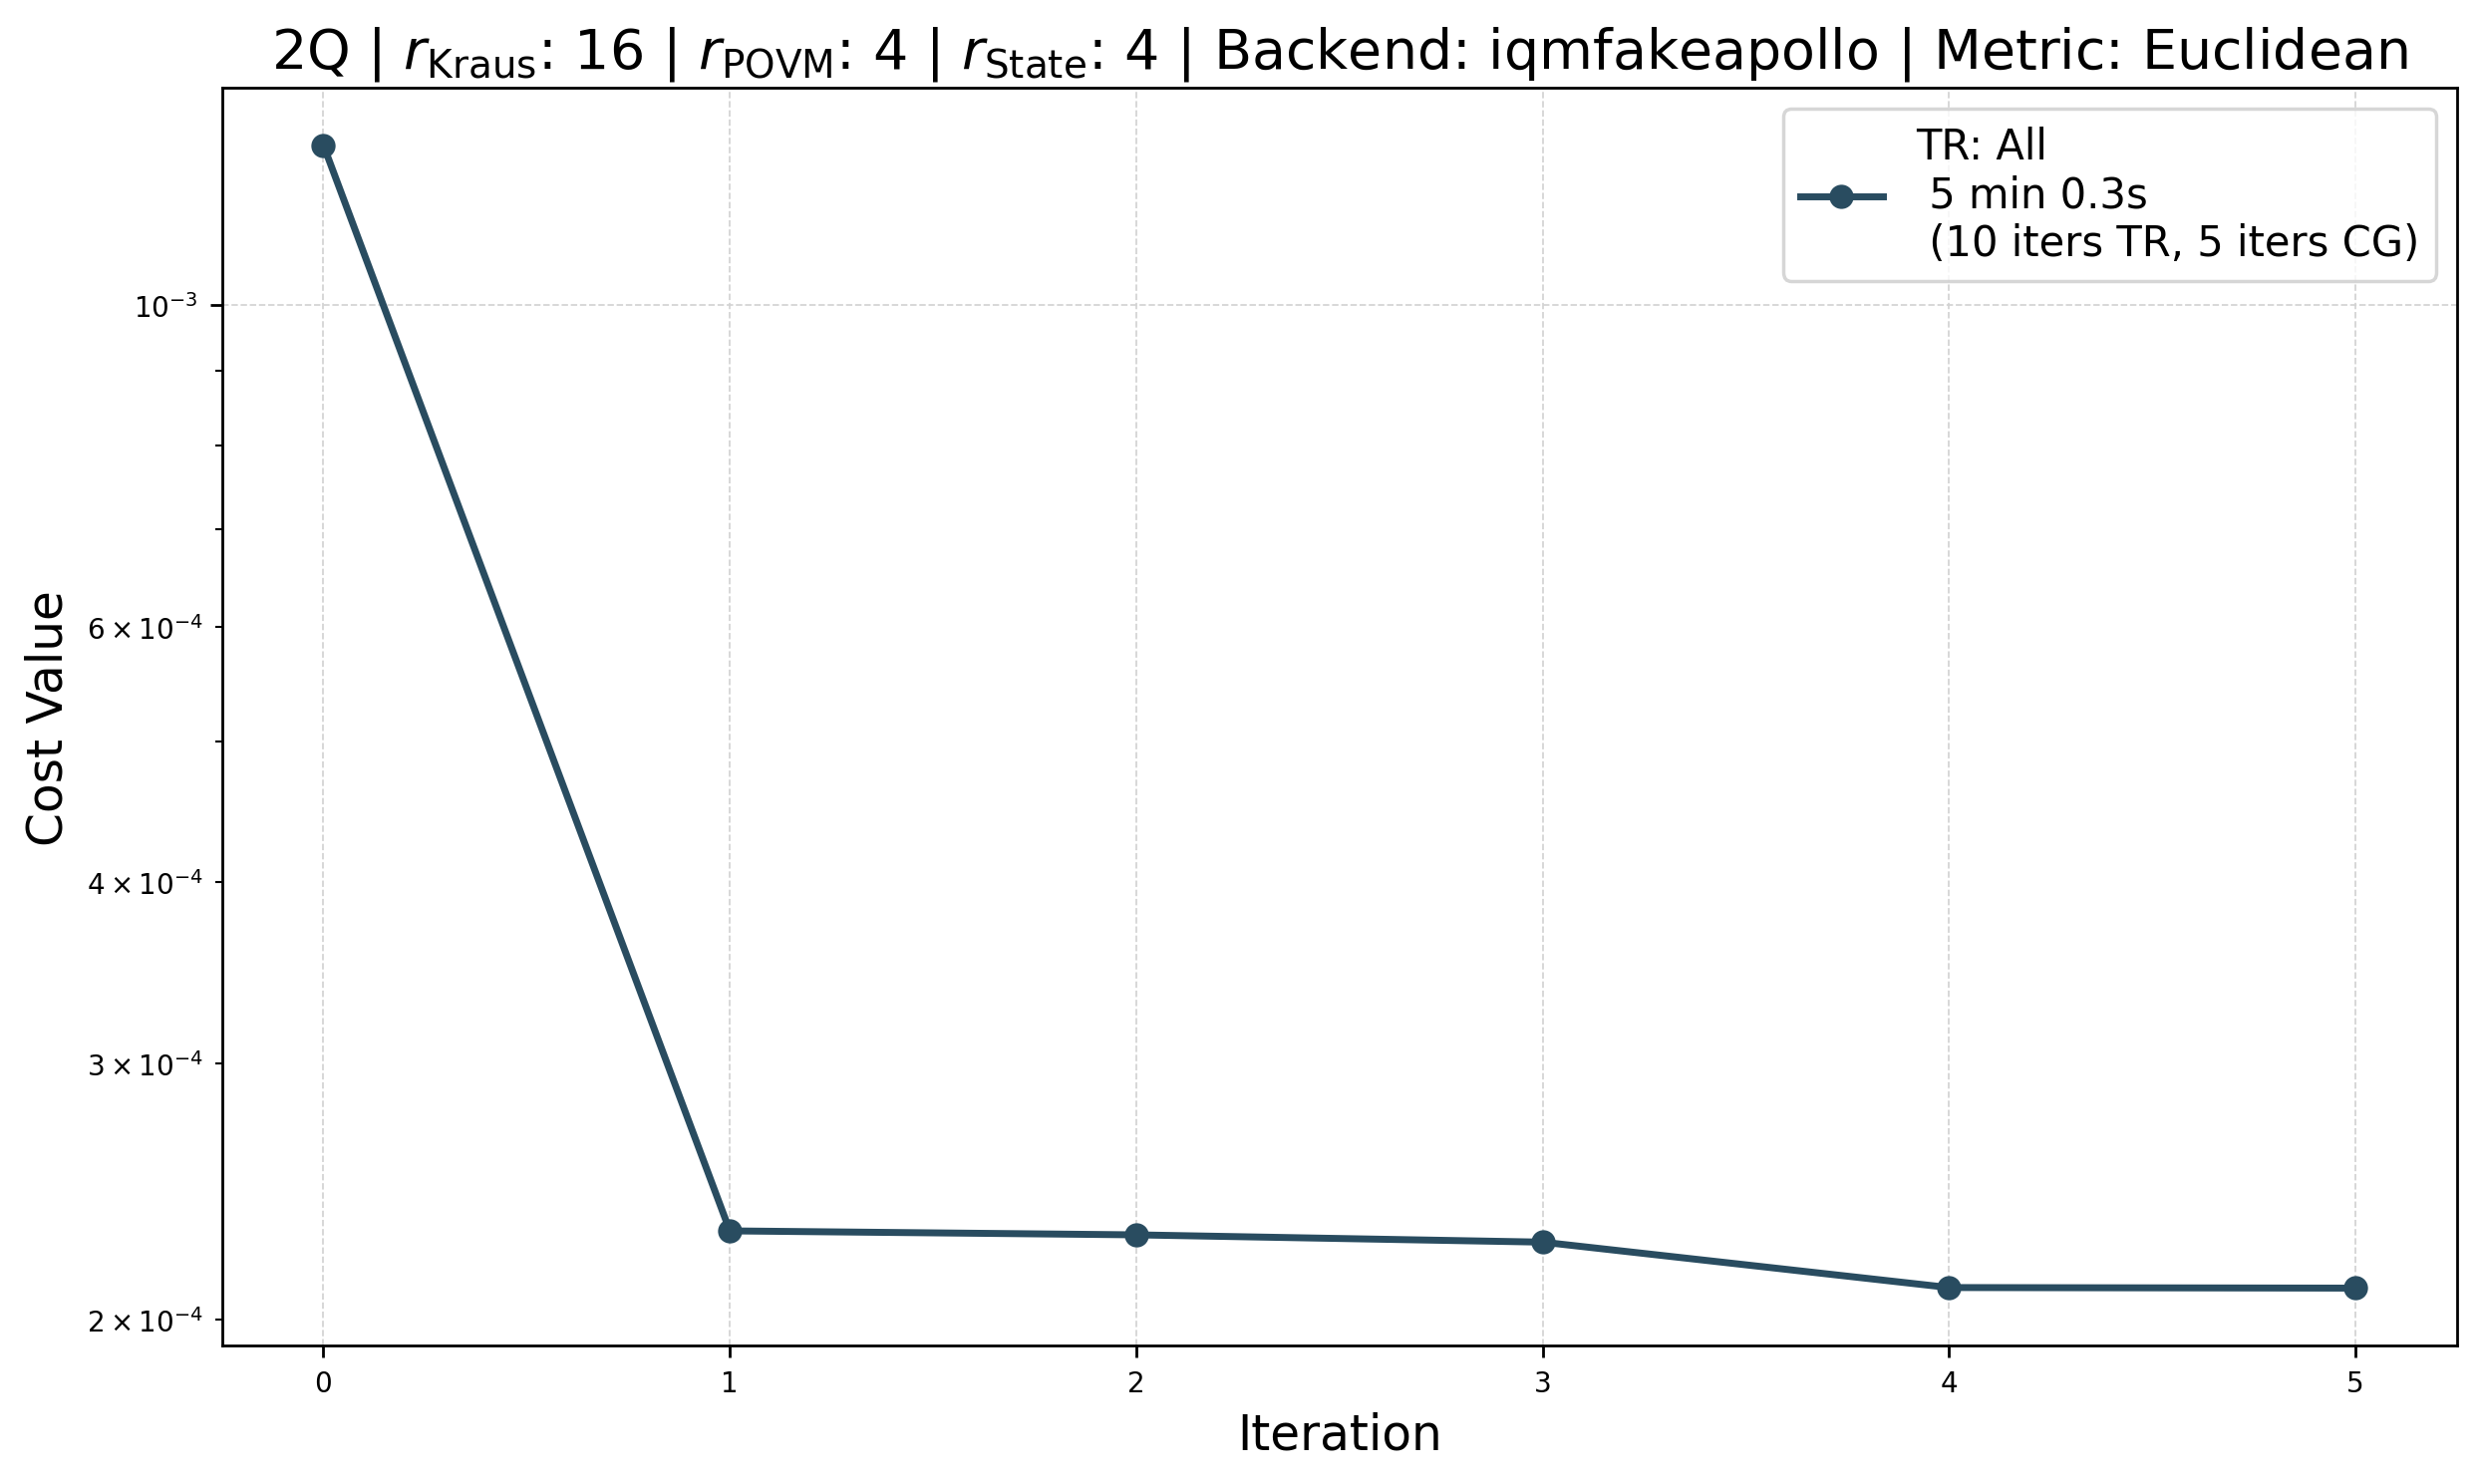

In [6]:
cost_fn_lists = [
    cost_fn_history_all_tr,
]

labels = [
    "TR: All \n 5 min 0.3s \n (10 iters TR, 5 iters CG)",
]

title = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: {backend} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

# Critical point?

In [7]:
optimized_operators_all_tr.keys()

dict_keys(['kraus', 'povm', 'state'])

In [8]:

kraus_tensor_opt = optimized_operators_all_tr["kraus"]
povm_psd_opt = optimized_operators_all_tr["povm"]
state_psd_opt = optimized_operators_all_tr["state"]

cost_fn_x_povm = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_opt, povm_psd=x, state_psd=state_psd_opt, **cost_fn_kwargs)
cost_fn_x_kraus = lambda x: cost_function_jax_mps(
    kraus_tensor=x, povm_psd=povm_psd_opt, state_psd=state_psd_opt, **cost_fn_kwargs)
cost_fn_x_state = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_opt, povm_psd=povm_psd_opt, state_psd=x, **cost_fn_kwargs)


In [9]:
# Sanity check for the cost function at each of these
print("POVM cost:", cost_fn_x_povm(povm_psd_opt))
print("Kraus cost:", cost_fn_x_kraus(kraus_tensor_opt))
print("State cost:", cost_fn_x_state(state_psd_opt))

POVM cost: 0.00021017325756106373
Kraus cost: 0.00021017325756106373
State cost: 0.00021017325756106373


In [10]:
# Compute the gradient for each of the elements.
metric = "euclidean"
grad_povm = riemannian_gradient_fn(x=povm_psd_opt, cost_fn=cost_fn_x_povm, operator_type="povm", metric=metric)
grad_kraus = riemannian_gradient_fn(x=kraus_tensor_opt, cost_fn=cost_fn_x_kraus, operator_type="kraus", metric=metric)
grad_state = riemannian_gradient_fn(x=state_psd_opt, cost_fn=cost_fn_x_state, operator_type="state", metric=metric)

In [11]:
# What is the relative magnitude of these gradients?
norm_grad_povm = jnp.linalg.norm(grad_povm)
norm_grad_kraus = jnp.linalg.norm(grad_kraus)
norm_grad_state = jnp.linalg.norm(grad_state)

norm_povm = jnp.linalg.norm(povm_psd_opt)
norm_kraus = jnp.linalg.norm(kraus_tensor_opt)
norm_state = jnp.linalg.norm(state_psd_opt)

print("Relative gradient norms:")
print("POVM:", norm_grad_povm / norm_povm)
print("Kraus:", norm_grad_kraus / norm_kraus)
print("State:", norm_grad_state / norm_state)

Relative gradient norms:
POVM: 6.675456562277802e-05
Kraus: 6.389972568011628e-05
State: 8.912433036736938e-08


# Compute Hessian at Critical point vs initial point

## Initial

In [16]:
kraus_mgst_init = np.array(kraus_tensor_init_jax)
mgst_tensors_init = get_mgst_tensors_from_psd_representation(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax)

kraus_contracted_mgst_init = mgst_tensors_init["kraus"]
povm_mgst_init = mgst_tensors_init["povm"]
state_mgst_init = mgst_tensors_init["state"]

cost_function_jax(kraus_contracted=kraus_contracted_mgst_init, povm_matrix=povm_mgst_init, state_vector=state_mgst_init, indices_list=indices_list, prob_matrix=prob_matrix)

Array(0.00134214, dtype=float64)

In [22]:
rhessian_kraus_init, euclidean_derivatives_init = compute_riemannian_hessian_kraus(
    kraus_tensor_mgst=kraus_mgst_init,
    povm_mgst=povm_mgst_init,
    state_mgst=state_mgst_init,
    indices_list=indices_list,
    prob_matrix=prob_matrix,
)

Computing 1st and 2nd order Euclidean derivatives ⏳
Computing Riemannian Hessian ⏳


In [23]:
num_gates, kraus_rank, dim, dim =  kraus_mgst_init.shape
n = kraus_rank * dim
p = dim
vect_dim = n * p

rhessian_kraus_mgst_init_mtrx = rhessian_kraus_init.reshape(2 * num_gates * vect_dim, 2 * num_gates * vect_dim)
rhessian_kraus_mgst_init_mtrx.shape

(2560, 2560)

## Critical

In [12]:
# Getting the mgst versions of the JAX tensors
mgst_tensors = get_mgst_tensors_from_psd_representation(kraus_tensor_opt, povm_psd_opt, state_psd_opt)

kraus_mgst_opt = np.array(kraus_tensor_opt) # the kraus tensor factorized is all we need for the Hessian computation
kraus_contracted_mgst_opt = mgst_tensors["kraus"]
povm_mgst_opt = mgst_tensors["povm"]
state_mgst_opt = mgst_tensors["state"]

In [13]:
cost_function_jax(kraus_contracted=kraus_contracted_mgst_opt, povm_matrix=povm_mgst_opt, state_vector=state_mgst_opt, indices_list=indices_list, prob_matrix=prob_matrix)

Array(0.00021017, dtype=float64)

In [14]:
rhessian_kraus_mgst, euclidean_derivatives_kraus = compute_riemannian_hessian_kraus(
    kraus_tensor_mgst=kraus_mgst_opt,
    povm_mgst=povm_mgst_opt,
    state_mgst=state_mgst_opt,
    indices_list=indices_list,
    prob_matrix=prob_matrix,
)

Computing 1st and 2nd order Euclidean derivatives ⏳
Computing Riemannian Hessian ⏳


In [ ]:
rhessian_kraus_mgst_mtrx = rhessian_kraus_mgst.reshape(2 * num_gates * vect_dim, 2 * num_gates * vect_dim)
rhessian_kraus_mgst_mtrx.shape

(2560, 2560)

# Look at eigenvalues

In [24]:
reigvals_kraus_init = jnp.linalg.eigvals(rhessian_kraus_mgst_init_mtrx)
reigvals_kraus_real_init = reigvals_kraus_init.real
reigvals_kraus_imag_init = reigvals_kraus_init.imag
jnp.linalg.norm(reigvals_kraus_imag_init), jnp.linalg.norm(reigvals_kraus_real_init)

(Array(2.67923937e-16, dtype=float64), Array(0.94825248, dtype=float64))

In [18]:
reigvals_kraus = jnp.linalg.eigvals(rhessian_kraus_mgst_mtrx)
reigvals_kraus_real = reigvals_kraus.real
reigvals_kraus_imag = reigvals_kraus.imag
jnp.linalg.norm(reigvals_kraus_imag), jnp.linalg.norm(reigvals_kraus_real)

(Array(2.31933689e-16, dtype=float64), Array(0.65774827, dtype=float64))

In [43]:
# Range of eigenvalues
print("Initial Hessian eigenvalues range:", jnp.min(reigvals_kraus_real_init), jnp.max(reigvals_kraus_real_init))
print("Optimized Hessian eigenvalues range:", jnp.min(reigvals_kraus_real), jnp.max(reigvals_kraus_real))

Initial Hessian eigenvalues range: -0.07934796697150964 0.32588787160031935
Optimized Hessian eigenvalues range: -0.004361185169919232 0.2533389564159021


In [ ]:
eigvals_real_all_kraus_ordered = jnp.sort(reigvals_kraus_real, descending=True)
eigvals_real_all_kraus_init_ordered = jnp.sort(reigvals_kraus_real_init, descending=True)

2026-01-27 00:03:05,653 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 00:03:05,665 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 00:03:05,783 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 00:03:05,793 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


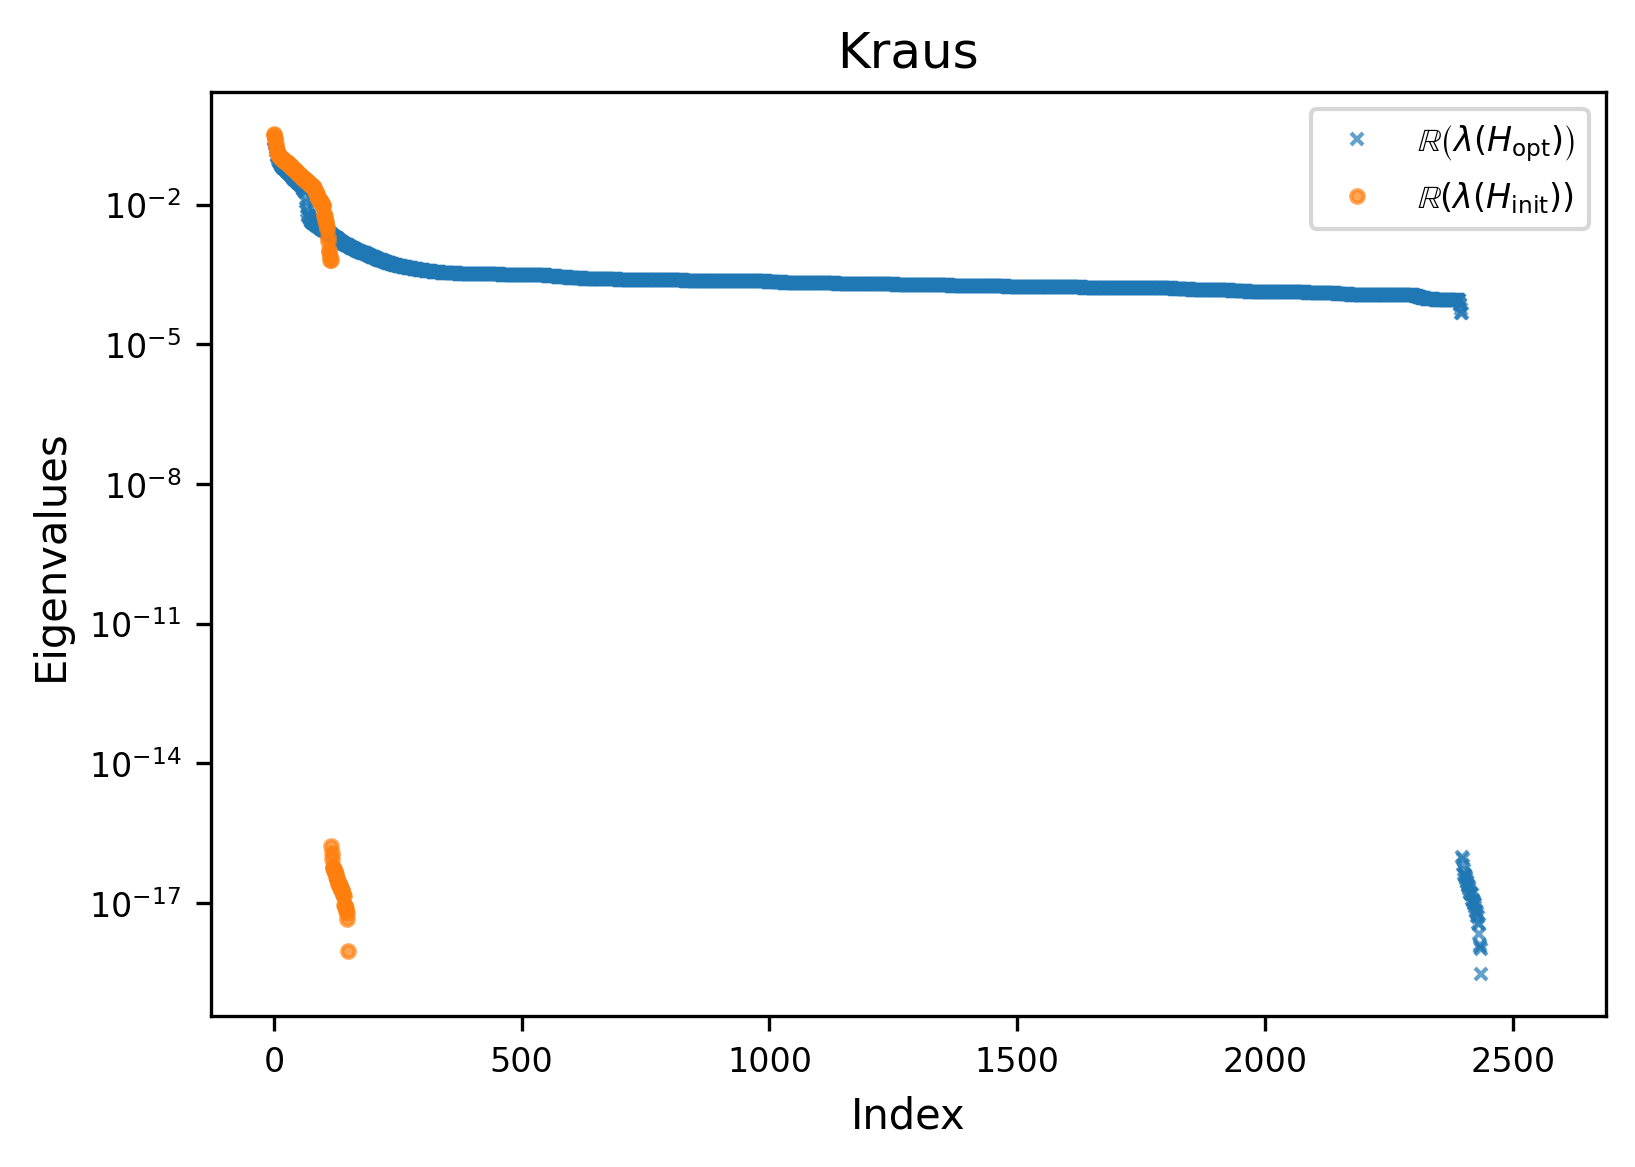

In [27]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus", fontsize=12)
plt.semilogy(eigvals_real_all_kraus_ordered, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{opt}}) \right)$", alpha=0.7)
plt.semilogy(eigvals_real_all_kraus_init_ordered, "o", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{init}}) \right)$", alpha=0.7)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [234]:
jnp.linalg.matrix_rank(rhessian_kraus_mgst_mtrx, rtol=1e-8)

Array(2480, dtype=int64)

In [235]:
jnp.linalg.matrix_rank(rhessian_kraus_mgst_init_mtrx, rtol=1e-8)

Array(2480, dtype=int64)

In [266]:
eps = 1e-5
print(f"Init eigvals: {jnp.sum(jnp.abs(reigvals_kraus_real_init) > eps)}, Optimized eigvals: {jnp.sum(jnp.abs(reigvals_kraus_real) > eps)}")

Init eigvals: 2480, Optimized eigvals: 2480


In [265]:
16 * 5 + 2480

2560

In [240]:
rhessian_kraus_mgst_init_mtrx.shape, kraus_tensor_init_jax.shape

((2560, 2560), (5, 16, 4, 4))

# Attempting to compute the spectral density

## Compute the hermitian matrices

In [ ]:
# Looking at a specific elements of Kraus Hessian.

n_kraus, p_kraus = get_isometry_dimensions_from_tensor(kraus_tensor_init_jax, operator_type='kraus')
vect_dim_kraus = n_kraus * p_kraus

kraus_isometries_init = tensor_to_isometry(kraus_tensor_init_jax, n_kraus, p_kraus)
kraus_isometries_opt = tensor_to_isometry(kraus_tensor_opt, n_kraus, p_kraus)

k = 0

xk_init = kraus_isometries_init[k]
xk_opt = kraus_isometries_opt[k]

rhessian_kraus_mgst_k_init = rhessian_kraus_init[ :, k, :, :, k, :].reshape(2 * vect_dim_kraus, 2 * vect_dim_kraus)

rhessian_kraus_mgst_k_opt = rhessian_kraus_mgst[ :, k, :, :, k, :].reshape(2 * vect_dim_kraus, 2 * vect_dim_kraus)

In [40]:
alpha0, alpha1 = 1, 1/2 # Riemannian metric even though the optimization is run using Euclidea metric 🤨

hessian_herm_init, Gx_init, Pt_init = perform_similarity_transform_on_hessian(hessian=rhessian_kraus_mgst_k_init, x=xk_init, alpha0=alpha0, alpha1=alpha1)

hessian_herm_opt, Gx_opt, Pt_opt = perform_similarity_transform_on_hessian(hessian=rhessian_kraus_mgst_k_opt, x=xk_opt, alpha0=alpha0, alpha1=alpha1)

In [41]:
jnp.allclose(hessian_herm_init, hessian_herm_init.conj().T), jnp.allclose(hessian_herm_opt, hessian_herm_opt.conj().T)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [75]:
# Eigenvalues of this specific k transformed hessian
eigvals_init = jnp.linalg.eigvals(hessian_herm_init).real
eigvals_opt = jnp.linalg.eigvals(hessian_herm_opt).real

# Minimum and max eigenvalues for initial and optimized
min_eigval_init, max_eigval_init = jnp.min(eigvals_init), jnp.max(eigvals_init)
min_eigval_opt, max_eigval_opt = jnp.min(eigvals_opt), jnp.max(eigvals_opt)
print("Init Hessian eigenvalues range:", min_eigval_init, max_eigval_init)
print("Opt Hessian eigenvalues range:", min_eigval_opt, max_eigval_opt)

Init Hessian eigenvalues range: -0.04420150077012773 0.19789531808292504
Opt Hessian eigenvalues range: -0.0025701014674593737 0.13496281416931302


In [268]:
d = 4
d**4 - d**2

240

In [275]:
# Rank of the hessian at init and opt from eigenvalues
eps_k = 9e-5
rank_init_exact = jnp.sum(jnp.abs(eigvals_init) > eps_k)
rank_opt_exact = jnp.sum(jnp.abs(eigvals_opt) > eps_k)

print("Exact rank from eigenvalues:")
print("Init rank:", rank_init_exact)
print("Opt rank:", rank_opt_exact)

Exact rank from eigenvalues:
Init rank: 496
Opt rank: 496


2026-01-27 13:56:53,116 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 13:56:53,122 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 13:56:53,183 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-27 13:56:53,188 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


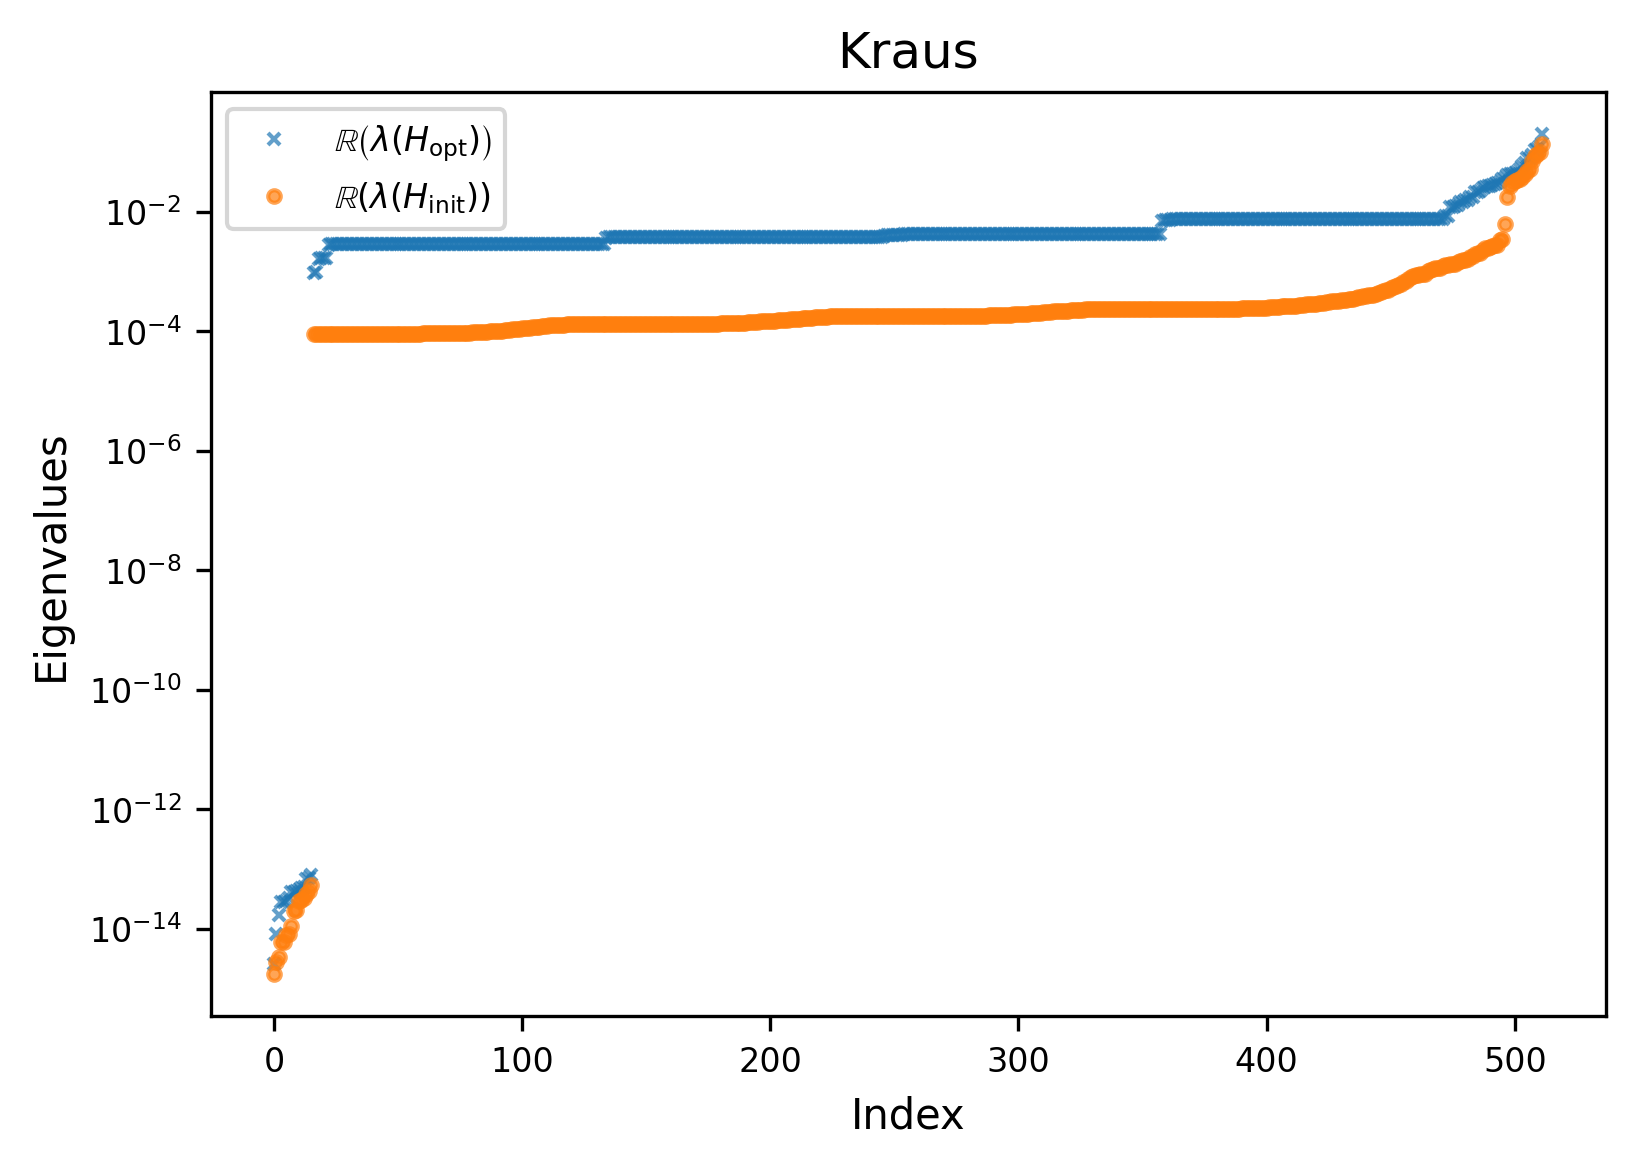

In [232]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus", fontsize=12)
plt.semilogy(jnp.sort(jnp.abs(eigvals_init)), "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{opt}}) \right)$", alpha=0.7)
plt.semilogy(jnp.sort(jnp.abs(eigvals_opt)), "o", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{init}}) \right)$", alpha=0.7)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

## SQL

In [ ]:
key = jax.random.PRNGKey(0)
dim_input = vect_dim_kraus

In [47]:
def hvp_init(v: jnp.ndarray) -> jnp.ndarray:
    """
    Function to compute the product of the Hessian matrix with a vector.

    Args:
        v (jnp.ndarray): The input vector.

    Returns:
        jnp.ndarray: The result of the Hessian-vector product.
    """
    H = hessian_herm_init
    dim = H.shape[0]
    vector_z_z_conj = jnp.concatenate([v, v.conj()])
    return (H @ vector_z_z_conj)[:dim//2]  # Return only the first half corresponding to Z

def hvp_opt(v: jnp.ndarray) -> jnp.ndarray:
    """
    Function to compute the product of the Hessian matrix with a vector.

    Args:
        v (jnp.ndarray): The input vector.

    Returns:
        jnp.ndarray: The result of the Hessian-vector product.
    """
    H = hessian_herm_opt
    dim = H.shape[0]
    vector_z_z_conj = jnp.concatenate([v, v.conj()])
    return (H @ vector_z_z_conj)[:dim//2]  # Return only the first half corresponding to Z

In [277]:
# k and m parameters
num_probes = 50
lanczos_order = 250

In [278]:
nodes_all_samples_init, weights_all_samples_init = generate_nodes_and_weights_for_all_probes(
    hvp=hvp_init,
    dim=dim_input,
    key=key,
    num_probes_k=num_probes,
    lanczos_order_m=lanczos_order,
    reorth=True,
)

SLQ probe 1/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 2/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 3/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 4/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 3-iterations ⚠️
SLQ probe 5/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 2-iterations ⚠️
SLQ probe 6/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 2-iterations ⚠️
SLQ probe 7/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 3-iterations ⚠️
SLQ probe 8/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 9/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 2-iterations ⚠️
SLQ probe 10/50
⚠️ Beta <= 1e-6. Possible nume

In [279]:
nodes_all_samples_opt, weights_all_samples_opt = generate_nodes_and_weights_for_all_probes(
    hvp=hvp_opt,
    dim=dim_input,
    key=key,
    num_probes_k=num_probes,
    lanczos_order_m=lanczos_order,
    reorth=True,
)

SLQ probe 1/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 6-iterations ⚠️
SLQ probe 2/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 3/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 5-iterations ⚠️
SLQ probe 4/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 6-iterations ⚠️
SLQ probe 5/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 7-iterations ⚠️
SLQ probe 6/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 3-iterations ⚠️
SLQ probe 7/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 2-iterations ⚠️
SLQ probe 8/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 2-iterations ⚠️
SLQ probe 9/50
⚠️ Beta <= 1e-6. Possible numerical instability of Lanczos encountered in: 4-iterations ⚠️
SLQ probe 10/50
⚠️ Beta <= 1e-6. Possible nume

## Rank through spectral density 

In [280]:
min_eigval, max_eigval = (-1e-1, 0.5)
num_points_grid = 500
sigma = 8e-4

In [281]:
grid_init, spectral_density_init, sigma_init = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples_init,
      weights_all_probes=weights_all_samples_init,
      num_points_grid=num_points_grid,
      sigma=sigma,
      min_eigval=min_eigval,
      max_eigval=max_eigval,
      normalize=True,
    )

σ used: 8.00e-04


In [282]:
grid_opt, spectral_density_opt, sigma_opt = smoothened_density_from_nodes_and_weights(
      nodes_all_probes=nodes_all_samples_opt,
      weights_all_probes=weights_all_samples_opt,
      num_points_grid=num_points_grid,
      sigma=sigma,
      min_eigval=min_eigval,
      max_eigval=max_eigval,
      normalize=True,
    )

σ used: 8.00e-04


In [283]:
sd_exact_init = exact_gaussian_spectral_density(eigvals_init, grid_init, sigma)
sd_exact_opt = exact_gaussian_spectral_density(eigvals_opt, grid_opt, sigma)

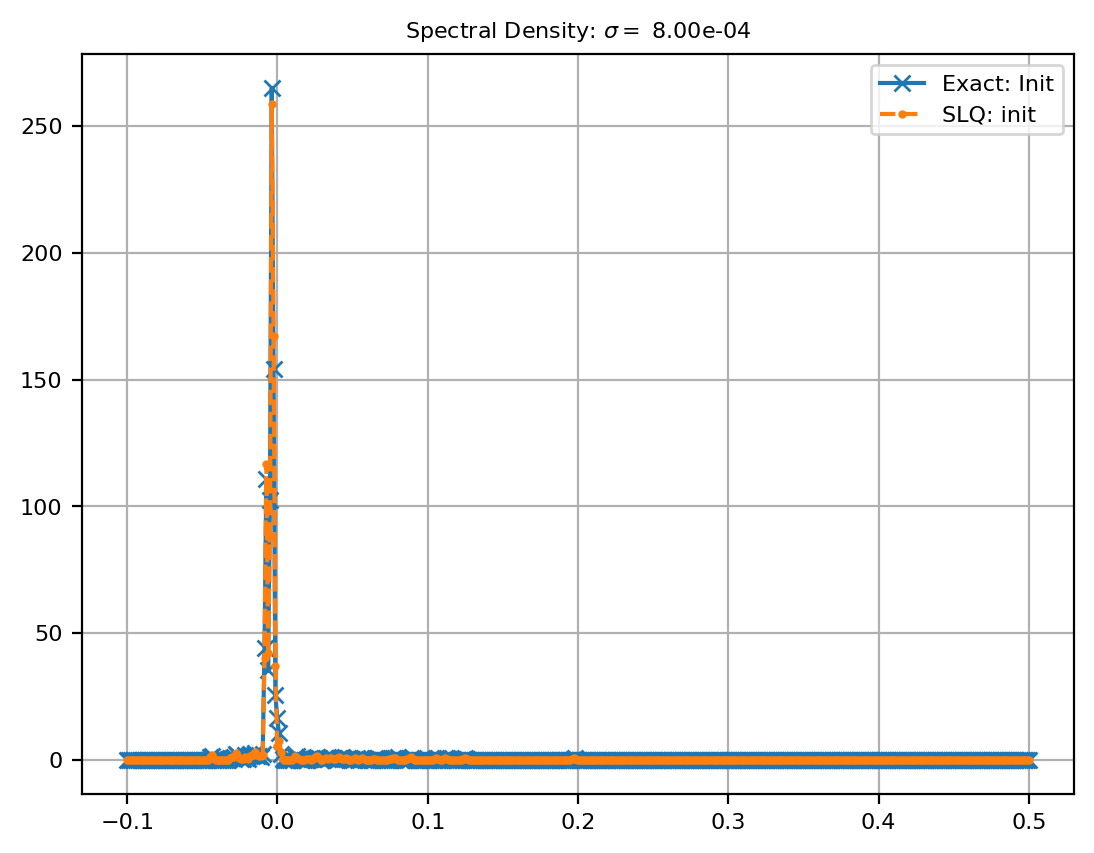

In [284]:
plt.figure(dpi=200)
plt.title(rf"Spectral Density: $\sigma =$ {sigma:.2e}")
plt.plot(grid_init, sd_exact_init, '-x', label="Exact: Init")
plt.plot(grid_init, spectral_density_init, '--o', markersize=2,label=r'SLQ: init')
plt.legend()
plt.grid()
plt.show()

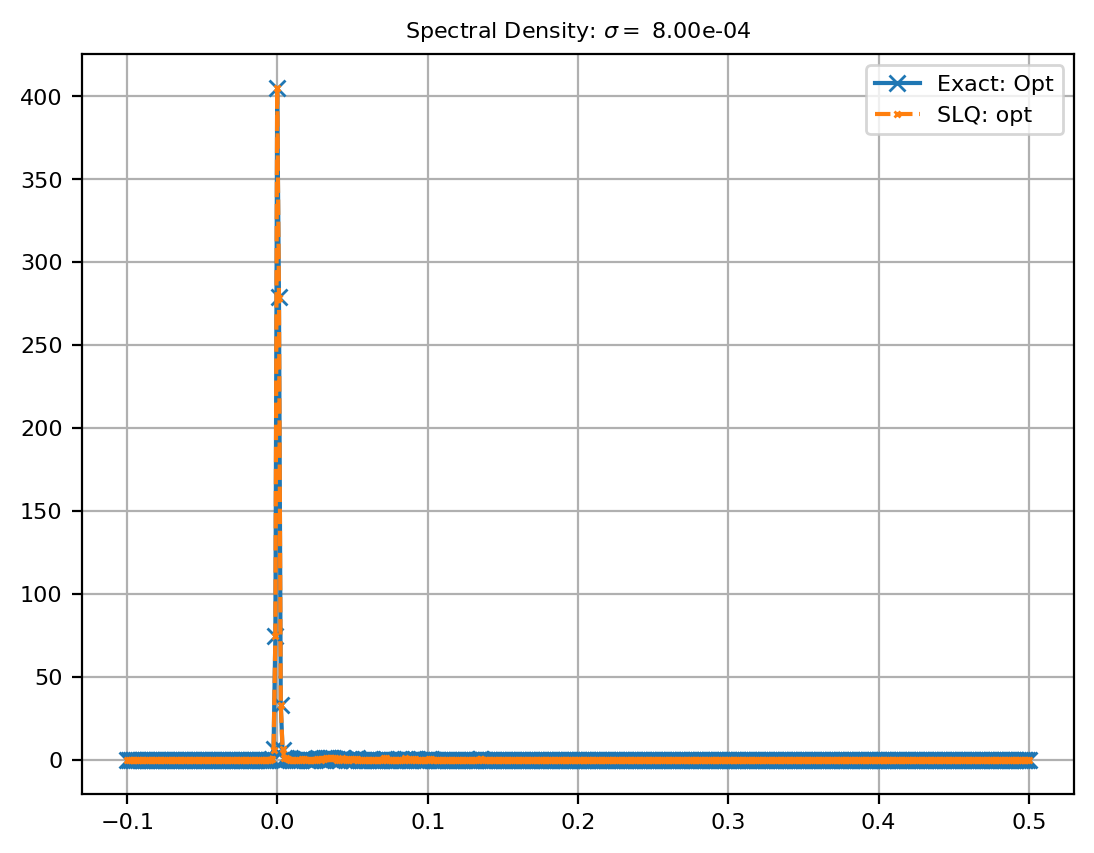

In [285]:
plt.figure(dpi=200)
plt.title(rf"Spectral Density: $\sigma =$ {sigma:.2e}")
plt.plot(grid_init, sd_exact_opt, '-x', label="Exact: Opt")
plt.plot(grid_init, spectral_density_opt, '--x', markersize=2,label=r'SLQ: opt')
plt.legend()
plt.grid()
plt.show()

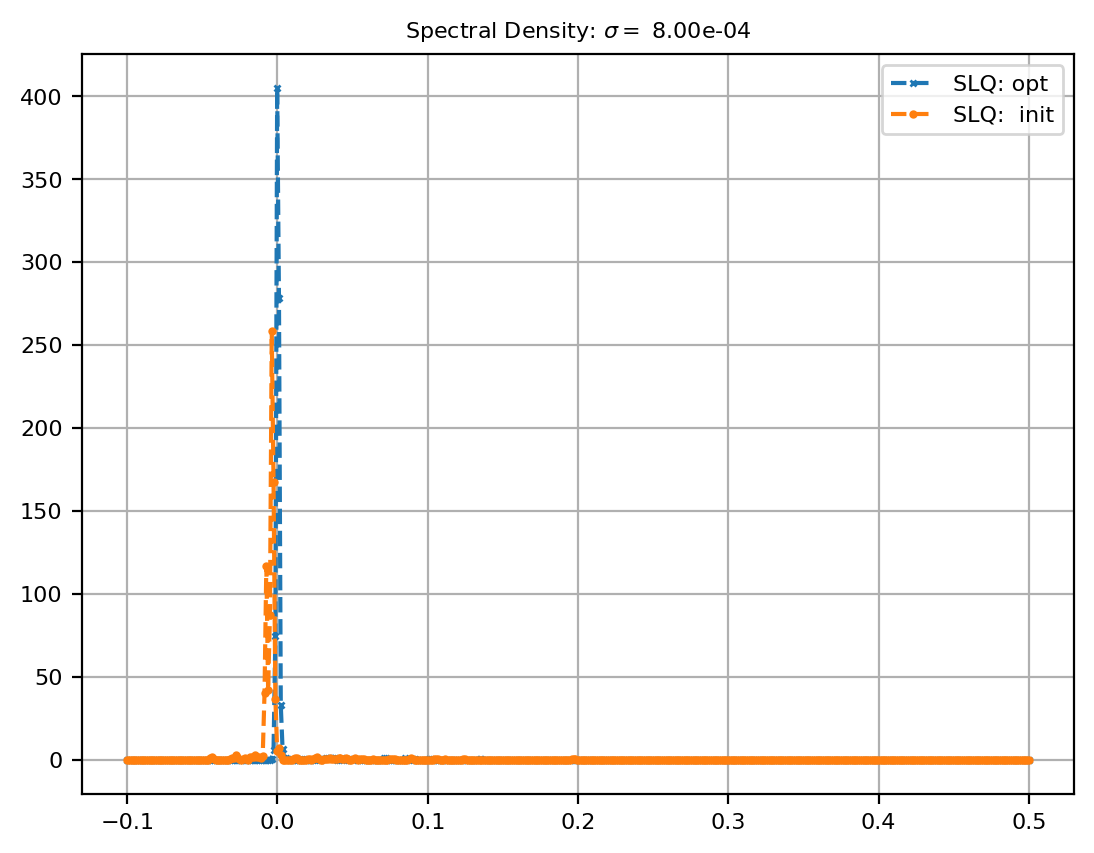

In [286]:
plt.figure(dpi=200)
plt.title(rf"Spectral Density: $\sigma =$ {sigma:.2e}")
plt.plot(grid_init, spectral_density_opt, '--x', markersize=2,label=r'SLQ: opt')
plt.plot(grid_init, spectral_density_init, '--o', markersize=2,label=r'SLQ:  init')
plt.legend()
plt.grid()
plt.show()

In [287]:
# Exact ranks from eigenvalues
print("Exact rank from eigenvalues:")
print("Init rank:", rank_init_exact)
print("Opt rank:", rank_opt_exact)

Exact rank from eigenvalues:
Init rank: 496
Opt rank: 496


In [288]:
rank_init, _ = rank_from_density(grid=grid_init, spectral_density=spectral_density_init, eps=eps_k, dim=dim_input)
rank_init * 2

Array(512., dtype=float64)

In [289]:
rank_opt, _ = rank_from_density(grid=grid_opt, spectral_density=spectral_density_opt, eps=eps_k, dim=dim_input)
rank_opt *2

Array(512., dtype=float64)

## How well do they estimate the trace

In [290]:
trace_exact_init = jnp.trace(hessian_herm_init) / (2 * dim_input) # the extra 2 because is the actual dimension of H
trace_exact_opt = jnp.trace(hessian_herm_opt) / (2 * dim_input) # the extra 2 because is the actual dimension of H
print("Trace from exact Hessian:")
print(f"Initial: {trace_exact_init.real:3e}")
print(f"Optimized: {trace_exact_opt.real:3e}")

Trace from exact Hessian:
Initial: -2.306473e-03
Optimized: 1.866252e-03


In [291]:
dx = grid_init[1] - grid_init[0]
grid = grid_init  # or grid_opt, they are the same
mean_slq_init = jnp.sum(grid * spectral_density_init) * dx
mean_slq_opt = jnp.sum(grid * spectral_density_opt) * dx
print("Mean from SLQ spectral density:")
print(f"Initial: {mean_slq_init.real:3e}")
print(f"Optimized: {mean_slq_opt.real:3e}")


Mean from SLQ spectral density:
Initial: -2.338656e-03
Optimized: 1.845643e-03


In [292]:
# Just checking normalization.
jnp.sum(spectral_density_init) * dx, jnp.sum(spectral_density_opt) * dx

(Array(1., dtype=float64), Array(1., dtype=float64))

# Now using the Ritz values directly to get the rank

In [293]:
print(f"Reminder of the eps: {eps_k:.2e}")

Reminder of the eps: 9.00e-05


In [294]:
rank_mean_init, rank_std_init, *_ = rank_from_ritz(nodes_all_probes=nodes_all_samples_init, weights_all_probes=weights_all_samples_init, eps=eps_k, dim=dim_input)

rank_mean_opt, rank_std_opt, *_ = rank_from_ritz(nodes_all_probes=nodes_all_samples_opt, weights_all_probes=weights_all_samples_opt, eps=eps_k, dim=dim_input)

print("Exact rank from eigenvalues:")
print("Init rank:", rank_init_exact)
print("Opt rank:", rank_opt_exact)
print("SLQ + indicator function rank estimates:")
print("Init rank SLQ:", rank_mean_init * 2, "+/-", rank_std_init * 2)
print("Opt rank SLQ:", rank_mean_opt * 2, "+/-", rank_std_opt * 2)

Exact rank from eigenvalues:
Init rank: 496
Opt rank: 496
SLQ + indicator function rank estimates:
Init rank SLQ: 512.0000000000001 +/- 3.016452674596985e-13
Opt rank SLQ: 473.8841879783308 +/- 31.707894098678732


# Note for me of the future:
In reality, we can use less number of lanczos steps and number of probes. The current parameters: k = 50 (probes) and m = 250 (lanczos steps) was just to check if the result would become more accurate. It did not. Surprisingly even increasing the number of probes did not decrease the variance.